# {Annuity Product Selection Analysis Using Customer Behavior and Macroeconomic Conditions}📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

Retail annuity products, specifically fixed, variable and indexed annuities, are designed to meet different financial needs related to risk tolerance, income stability, and long-term growth. However, product selection is oftern influenced by a combination of customer demographics (i.e age, income, and retirement horizon) and external economic conditions such as interest rates and inflation, rather than a clear data-driven matching process.

In practice, this leads to measurable inefficiencies:
- Customers nearing retirement (ages 55–70) may select variable annuities despite shorter time horizons, exposing them to unnecessary market volatility.
- Younger or higher-income individuals may underutilize growth-oriented products due to conservative defaults or lack of guidance.
- Periods of rising interest rates can shift product demand toward fixed annuities, but is this relationship being quantified at the customer-segment level?

From a data management and reporting perspective, annuity providers maintain large volumes of structured data (customer profiles, transaction histories, and product allocations), but this data is often used descriptively (reporting past sales) rather than analytically (understanding why certain products are selected and whether those selections align with customer characteristics and market conditions).

This project aims to analyze how specific variables:
- Age (grouped into pre-retirement vs retirement cohorts)
- Income level (segmentented into quantiles)
- Proxy indicators of risk tolerance (derived from financial behavior)
- Macroeconomic conditions (interest rate levels over time)
influence the likelihood of a customer selecting a particular annuity product type.

By integrating customer level financial data with external economic indicators, this analysis will identify statistically significant relationships between customer profiles, market conditions, and product selection patterns. The goal is predictive and explanatory insights that can support:
- targeted product recommendations
- improved segmentation strategies
- and better alignment between customer needs and financial products


## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

How do customer demographic(age and income) and macroeconomic conditions(interest rates) influence the liklihood of selecting fixed, variable, or indexed annuity products?

Addition questions:
- How does annuity product selection vary across age groups (<40, 40–55, 55+)?
- Does income level significantly affect the likelihood of choosing higher-risk products (variable annuities)?
- How do changes in interest rates over time impact the distribution of annuity product types?
- Which factors (age, income, or economic conditions) have the greatest predictive power in determining product selection?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

- A predictive model outputting probabilities such as: “A 60-year-old with moderate income during high interest rate periods has a 72% probability of selecting a fixed annuity”

- Ranked feature importance:
    - Age -> strongest predictor
    - Interest rate -> secondary
    - Income -> moderate

- Visual confirmation of trends: clear seperation of product types across demographic groups



## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

Economic Indicators (API) : from Federal Reserve Economic Data (https://fred.stlouisfed.org/)

Key variables: 
- Federal interest rates
- Inflation rate
- Treasury yields

Assign economic conditions to each observation and create low rate vs high rate environments.

bank.csv from Bank Marketing Dataset on Kaggle
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?resource=download

Key variables:
- age
- job / income proxy
- marital status
= education

Represent customer demographic and financial profiles and create derived features.

Use pandas to generate a simulated annuity products dataset:
- real annuity product selection data is proprietary
- Customer attributes such as age, income, and prevailing interest rates were used to assign annuity product types in a way that reflects realistic market tendencies


## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

This project will follow a structured data analytics workflow to examine how customer demographics and economic conditions influence annuity product selection.

1. Data Acquisition and Integration

Three datasets will be used:

A customer financial behavior dataset (CSV file)
Macroeconomic data retrieved via the Federal Reserve Economic Data
A simulated annuity product dataset generated within the notebook

The customer dataset will provide demographic variables such as age and income. Economic data (e.g., interest rates) will be mapped to each observation using a time-based or scenario-based assignment. A simulated dataset will assign annuity product types (fixed, variable, indexed) to each customer using probabilistic rules based on financial assumptions.

2. Data Cleaning and Preprocessing
Handle missing or inconsistent values in customer data
Normalize and clip income values to realistic ranges
Convert continuous variables into categorical features:
Age → grouped into (<40, 40–55, 55+)
Income → segmented into low, medium, and high tiers
Ensure all datasets are aligned in structure for merging
3. Feature Engineering
Create derived variables:
Age group
Income tier
Interest rate category (low vs high rate environment)
Generate the target variable:
annuity_product (fixed, variable, indexed) using probabilistic assignment
Merge product metadata (risk level, return type, fee level) into the final dataset
4. Exploratory Data Analysis (EDA)

EDA will be conducted to identify patterns and relationships:

Distribution of annuity product types across age groups
Relationship between income tiers and product selection
Impact of interest rate levels on product distribution
Correlation analysis between variables

Visualizations will include:

Bar charts (product type vs demographic groups)
Heatmaps (income vs product type)
Line plots (interest rates vs product trends)
5. Predictive Modeling

A classification model will be developed to predict annuity product selection:

Logistic regression and/or decision tree classifier
Input variables:
Age group
Income tier
Interest rate
Output:
Probability of selecting each annuity product type
6. Model Evaluation and Interpretation
Evaluate model performance using accuracy and confusion matrix
Analyze feature importance to determine which variables most influence product selection
Interpret results in the context of financial decision-making
7. Insight Generation

The final step will translate analytical results into business insights:

Identify which customer segments are most likely to choose each product type
Evaluate how economic conditions shift product preferences
Discuss how these insights could support better targeting and product recommendations in an annuity business context

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

Kaggle - Bank Marketing dataset https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?resource=download
Federal Reserve Economic Data (https://fred.stlouisfed.org/)
ChatGPT

# Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
import seaborn as sns


from dotenv import load_dotenv
from pandas_datareader import data as pdr


load_dotenv()

api_key = os.getenv("FRED_API_KEY")

if api_key is None:
    raise ValueError("FRED_API_KEY not found in environment variables.")
else:
    print("FRED_API_KEY successfully loaded.")


FRED_API_KEY successfully loaded.


# Setup and Prepare



In [2]:
bank_df = pd.read_csv("data/bank.csv", sep=",")

bank_df.head()
bank_df.info()
bank_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [3]:
bank_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

The Bank Marketing dataset contains 11,162 customer records with 17 features describing demographic, financial, and behavioral attributes. The dataset includes both numerical variables(age, balance, duration, campaign) and categorical variables (job, marital status, education, loan status). No missing values are present but several categorical fields require encoding for machine learning. The dataset will serve as the primary customer behavioral dataset for modeling annuity product selection. 

In [4]:
# Convert categorical variables (important for ML later)
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome", "deposit"
]

for col in categorical_cols:
    bank_df[col] = bank_df[col].astype("category")

In [5]:
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2024, 12, 31)

fed_funds = pdr.DataReader("FEDFUNDS", "fred", start, end)


In [6]:
fed_funds = fed_funds.reset_index()
fed_funds["year"] = fed_funds["DATE"].dt.year

# yearly average interest rate
annual_rates = fed_funds.groupby("year")["FEDFUNDS"].mean().to_dict()


In [7]:
base = bank_df.copy()

base.describe()

# Add a unique customer ID for easier merging and analysis
base["customer_id"] = range(1, len(base) + 1)

In [8]:
job_income_map = {
    "management": 90000,
    "technician": 70000,
    "admin.": 50000,
    "services": 40000,
    "blue-collar": 45000,
    "retired": 30000,
    "student": 25000,
    "unemployed": 20000
}

base["base_income"] = base["job"].map(job_income_map)

# Use median because income is usually skewed; mean would be pulled upward by high-income jobs.
base["base_income"] = base["base_income"].fillna(base["base_income"].median())

In [9]:
base["year"] = np.random.choice(list(annual_rates.keys()), size=len(base))
base["interest_rate"] = base["year"].map(annual_rates)

In [10]:
rate_min = base["interest_rate"].min()
rate_max = base["interest_rate"].max()

base["rate_scaled"] = (base["interest_rate"] - rate_min) / (rate_max - rate_min)

In [11]:
base["macro_adjustment"] = 0.9 +(base["rate_scaled"] * 0.2)

In [12]:
base["income"] = (base["base_income"] * base["macro_adjustment"] +
                  np.random.normal(0, 10000, len(base))).clip(20000, 200000)

base.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,previous,poutcome,deposit,customer_id,base_income,year,interest_rate,rate_scaled,macro_adjustment,income
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,0,unknown,yes,1,50000.0,2012,0.140000,0.011850,0.902370,36759.132270
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,0,unknown,yes,2,50000.0,2010,0.175000,0.018762,0.903752,37368.347429
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,0,unknown,yes,3,70000.0,2015,0.132500,0.010369,0.902074,63551.168922
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,0,unknown,yes,4,40000.0,2024,5.143333,1.000000,1.100000,31996.754636
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,0,unknown,yes,5,50000.0,2012,0.140000,0.011850,0.902370,59513.276365


Income was not directly available in the dataset, so it was synthetically generated using a hybrid approach. A base income level was assigned using job categories to reflect individual earning potential. This base value was then adjusted using macroeconomic conditions derived from Federal Reserve interest rate data. Interest rates were normalized and used to create a macro adjustment factor, simulating the effect of broader economic conditions on income levels. Random noise was added to preserve variability across individuals. This approach ensures that income reflects both micro-level characteristics and macroeconomic trends.

In [13]:
def compute_risk_score(row):
    score = 0

    # Age (younger = more risk tolerance)
    if row["age"] < 40:
        score += 2
    elif row["age"] < 55:
        score += 1
    else:
        score -= 1

    # Income (higher = more risk capacity)
    if row["income"] > 90000:
        score += 2
    elif row["income"] > 50000:
        score += 1

    # Loans (constraints reduce risk tolerance)
    if row["housing"] == "yes":
        score -= 1
    if row["loan"] == "yes":
        score -= 1

    # Engagement (more engagement = openness to risk products)
    if row["previous"] > 0:
        score += 1

    # Normalize to 1–10 scale
    return np.clip(score + 5, 1, 10)

base["risk_score"] = base.apply(compute_risk_score, axis=1)


In [14]:
base["retirement_horizon"] = np.maximum(65 - base["age"], 1)

In [15]:
def assign_product(row):
    probs = {
        "fixed": 0.33,
        "variable": 0.33,
        "indexed": 0.34
    }

    if row["risk_score"] <= 3:
        probs["fixed"] += 0.30
    elif row["risk_score"] >= 7:
        probs["variable"] += 0.30

    if row["retirement_horizon"] < 10:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.10

    if row["interest_rate"] > 3:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.20

    total = sum(probs.values())
    probs = {k: v / total for k, v in probs.items()}

    return np.random.choice(list(probs.keys()), p=list(probs.values()))

base["annuity_product"] = base.apply(assign_product, axis=1)

In [16]:
base["year"] = np.random.choice(list(annual_rates.keys()), size=len(base))
base["interest_rate"] = base["year"].map(annual_rates)
base["annuity_product"] = base.apply(assign_product, axis=1)

In [17]:
products = pd.DataFrame({
    "product": ["fixed", "variable", "indexed"],
    "risk_level": ["low", "high", "medium"],
    "avg_return": [0.03, 0.07, 0.05],
    "fee_percent": [0.01, 0.025, 0.015]
})


In [31]:
model = base.copy()

product_meta = pd.DataFrame({
    "annuity_product": ["fixed", "variable", "indexed"],
    "risk_level": ["low", "high", "medium"],
    "avg_return": [0.03, 0.07, 0.05]
})

model = model.merge(product_meta, on="annuity_product")
print(model.columns)
model.head()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'customer_id', 'base_income', 'year',
       'interest_rate', 'rate_scaled', 'macro_adjustment', 'income',
       'risk_score', 'retirement_horizon', 'annuity_product', 'age_group',
       'risk_level', 'avg_return'],
      dtype='object')


,age,job,marital,education,default,balance,housing,loan,contact,day,...,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product,age_group,risk_level,avg_return
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,0.101667,0.011850,0.902370,36759.132270,3,6,fixed,55+,low,0.03
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,1.831667,0.018762,0.903752,37368.347429,4,9,fixed,55+,low,0.03
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,0.132500,0.010369,0.902074,63551.168922,6,24,variable,40-55,high,0.07
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,0.395000,1.000000,1.100000,31996.754636,3,10,fixed,40-55,low,0.03
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,0.395000,0.011850,0.902370,59513.276365,7,11,variable,40-55,high,0.07


The base dataframe is used as an intermediate feature-engineerign layer where customer attributes and macroeconomic variables are constructed and validated. The model dataframe represents the finalized modeling dataset, including the target variable (annuity_product) and any additional product level attributes and is used for machine learning and final analysis.

In [32]:
print(base.columns)
base.head()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'customer_id', 'base_income', 'year',
       'interest_rate', 'rate_scaled', 'macro_adjustment', 'income',
       'risk_score', 'retirement_horizon', 'annuity_product', 'age_group'],
      dtype='object')


,age,job,marital,education,default,balance,housing,loan,contact,day,...,base_income,year,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product,age_group
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,50000.0,2011,0.101667,0.011850,0.902370,36759.132270,3,6,fixed,55+
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,50000.0,2018,1.831667,0.018762,0.903752,37368.347429,4,9,fixed,55+
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,70000.0,2015,0.132500,0.010369,0.902074,63551.168922,6,24,variable,40-55
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,40000.0,2016,0.395000,1.000000,1.100000,31996.754636,3,10,fixed,40-55
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,50000.0,2016,0.395000,0.011850,0.902370,59513.276365,7,11,variable,40-55


# Exploratory Data Analysis


This exploratory data analysis examines how customer demographics, financial capacity, behavioral indicators, and macroeconomic conditions influence annuity product selection. The dataset combines:

Customer-level data from the bank marketing dataset
Simulated financial variables (income, risk score, retirement horizon)
Macroeconomic indicators (interest rates)

The objective of this EDA is to:

Understand variable distributions
Identify relationships between features
Detect data quality issues
Prepare the dataset for machine learning

This bar chart examines how annuity product selection varies across age groups. Customers are segmented into three life stages: under 40, 40–55, and 55+.



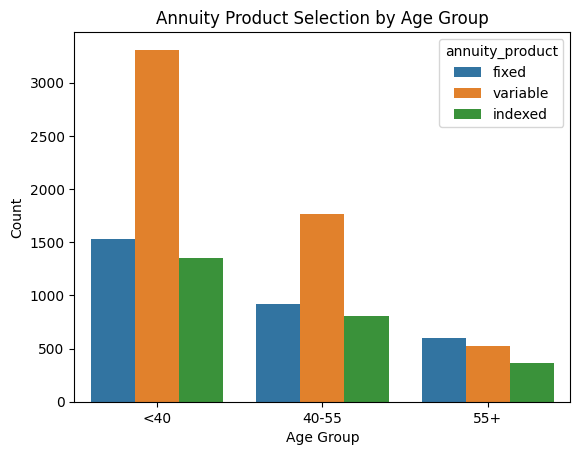

In [41]:
# Create age groups
base["age_group"] = pd.cut(base["age"], bins=[0, 40, 55, 100], labels=["<40", "40-55", "55+"])

plt.figure()
sns.countplot(data=base, x="age_group", hue="annuity_product")
plt.title("Annuity Product Selection by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

The visualization shows a clear behavioral trend:

Younger customers (<40) tend to select more variable annuities
Middle-aged customers show a more balanced distribution
Older customers (55+) prefer fixed annuities

This aligns with financial theory, where risk tolerance decreases with age and proximity to retirement increases demand for stable income products.

This boxplot shows how income levels vary across different annuity product types.



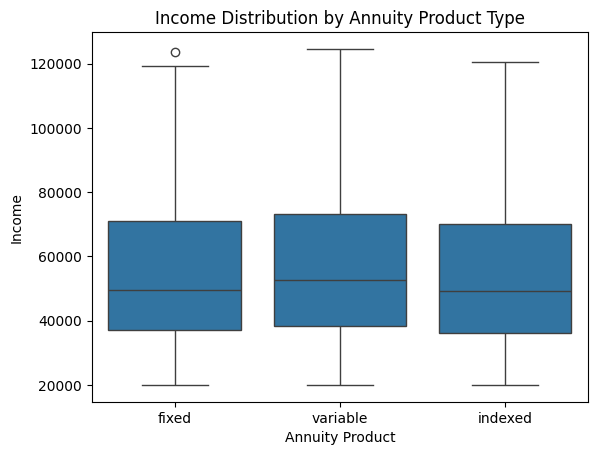

In [42]:
plt.figure()
sns.boxplot(data=base, x="annuity_product", y="income")
plt.title("Income Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Income")
plt.show()

Key observations:

Customers selecting variable annuities generally have higher median income
Fixed annuity customers tend to have lower income levels
Indexed products fall in the middle range

This suggests that income is strongly associated with risk capacity, where higher-income individuals are more likely to accept market exposure in exchange for higher potential returns.

This line plot shows how annuity product demand changes over time under different interest rate environments.



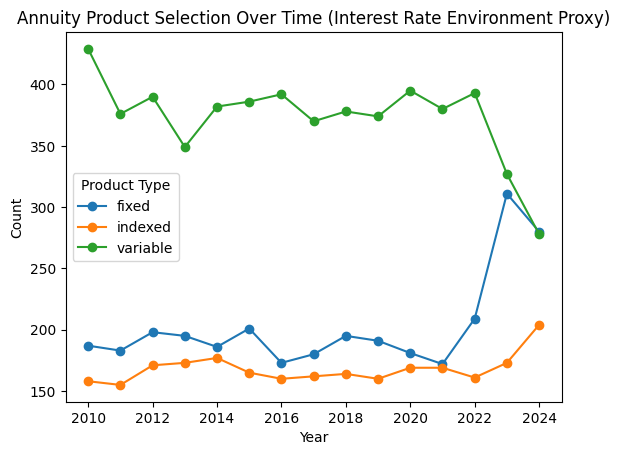

In [43]:
rate_trend = base.groupby(["year", "annuity_product"]).size().unstack()

rate_product = base.groupby(["year", "annuity_product"]).size().unstack()

rate_product.plot(kind="line", marker="o")
plt.title("Annuity Product Selection Over Time (Interest Rate Environment Proxy)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Product Type")
plt.show()

Findings:

During high interest rate periods (e.g., 2022–2024), fixed annuity demand increases
During low interest rate periods (e.g., 2020–2021), variable annuities become more common
Indexed products remain relatively stable across time

This demonstrates that macroeconomic conditions (interest rates from FRED) influence product preference at the market level, shifting demand rather than changing individual risk profiles.

Below is a correlation heatmap that highlights the relationships between demographic, financial, behavioral, and engineered features in the dataset.

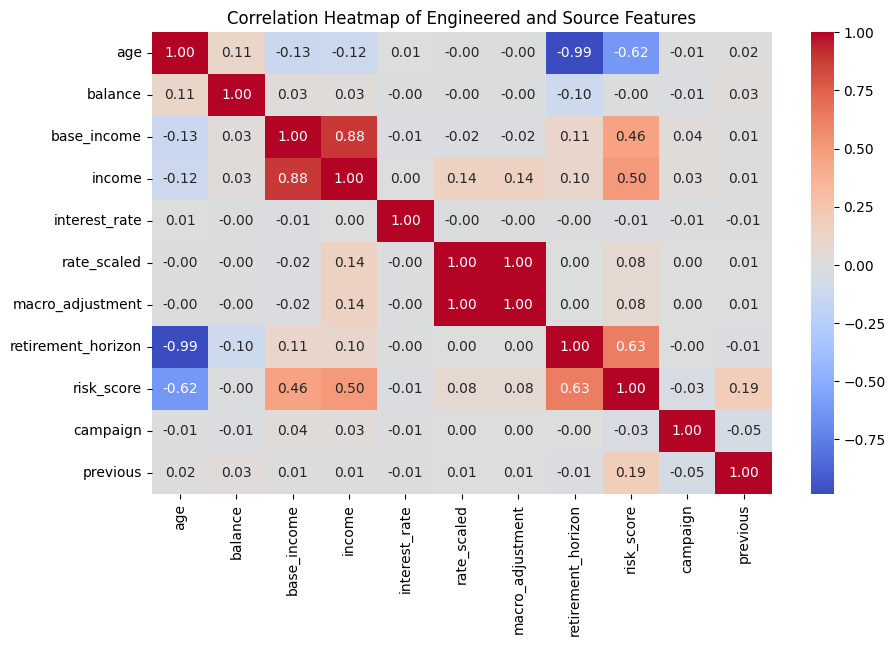

In [50]:
plt.figure(figsize=(10,6))

numeric_cols = [
    "age", # core demographic
    "balance", # raw financial behavior
    "base_income", # engineered baseline income
    "income", # final income after macro adjustment and noise
    "interest_rate", # macroeconomic factor
    "rate_scaled", # transformation
    "macro_adjustment", # macroeconomic adjustment
    "retirement_horizon", # lifetime financial planning # lifecycle
    "risk_score", # risk assessment # key engineered feature
    "campaign", # marketing campaign  # behavioral
    "previous" # previous contact history # behavioral
]

corr = base[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Engineered and Source Features")
plt.show()

Several strong correlations are expected due to the feature engineering process. For example, age and retirement horizon exhibit a near-perfect negative correlation (-0.99), as retirement horizon was directly derived from age. Similarly, base income and income show a strong positive correlation (0.88), reflecting that income was generated using base income with macroeconomic adjustments.

More importantly, the heatmap reveals meaningful behavioral relationships. Risk score shows a moderate positive correlation with income (0.50) and base income (0.46), indicating that higher-income individuals tend to have higher risk tolerance. Additionally, risk score is negatively correlated with age (-0.62) and positively correlated with retirement horizon (0.63), suggesting that younger individuals with longer investment horizons are more likely to take on risk. These findings align with established financial theory and confirm that the engineered risk score is capturing realistic customer behavior.

Interest rates show minimal correlation with most variables, which is expected since they represent external macroeconomic conditions rather than individual customer attributes. Their influence is incorporated during the annuity product assignment process rather than directly affecting demographic features.

Finally, behavioral variables such as campaign and previous contact attempts exhibit weak correlations with financial features, indicating that they capture independent aspects of customer behavior. This diversity of signals is beneficial for predictive modeling, as it reduces redundancy and improves model generalization.

Overall, the heatmap validates both the internal consistency of the engineered features and the presence of meaningful relationships that will support downstream machine learning models.

In [48]:
# To avoid mulicollinearity for cleaner model later on
drop_cols = ["base_income", "rate_scaled", "macro_adjustment"]

This boxplot evaluates whether the engineered risk_score meaningfully influences annuity product assignment. 

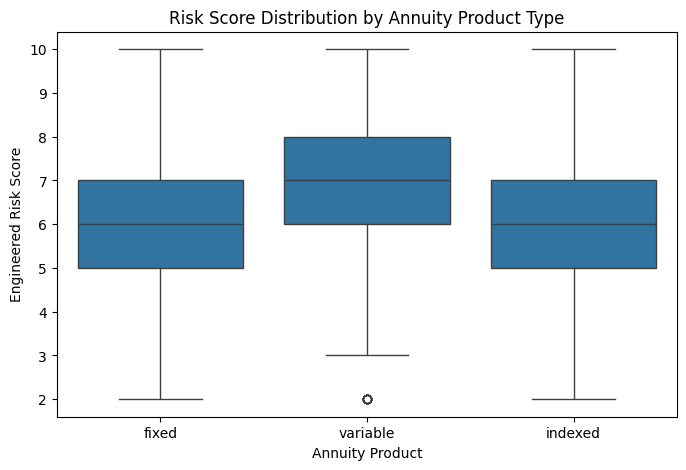

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=base, x="annuity_product", y="risk_score")
plt.title("Risk Score Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Engineered Risk Score")
plt.show()

The median risk score for customers selecting variable annuities is higher than for those selecting fixed or indexed annuities, indicating that higher-risk individuals are more likely to be associated with variable products. The interquartile range is also shifted upwards for variable annuities, suggesting a concentrated distribution of higher-risk customers. In contrast, the interquartile ranges for fixed and indexed annuities exhibit broader distributions with lower median values, reflecting more conservative or moderate risk profiles.
However, there is noticeable overlap between all three product categories, indicating that risk score is not the sole determinant of product selection. This aligns with the project design, where additional factors such as retirement horizon and macroeconomic conditions (interest rates) also influence the probabilistic assignment of annuity products.

In [46]:
base.groupby("annuity_product")["risk_score"].agg(["mean", "median", "std"])

,mean,median,std
annuity_product,,,
fixed,6.230440,6.0,1.497280
indexed,6.370885,6.0,1.423195
variable,6.648330,7.0,1.359245


This aggregation summarizes the distribution of risk scores across annuity product types using the mean, median, and standard deviation. The mean provides the average risk level within each product category, while the median represents the typical customer and is less sensitive to extreme values. The standard deviation measures the variability of risk scores within each group.

The results show that variable annuities have both the highest mean (6.65) and median (7), indicating that customers selecting variable products tend to have higher risk tolerance. Fixed and indexed annuities have lower and similar medians (6), suggesting more moderate risk profiles.

Additionally, the standard deviation is slightly lower for variable annuities, indicating that high-risk customers are more consistently grouped within this product type. In contrast, fixed annuities show a wider spread of risk scores, suggesting a more diverse set of customer risk profiles.

These findings reinforce the validity of the engineered risk score and confirm that it meaningfully influences annuity product assignment while still allowing for realistic variation in customer behavior.

# Data Cleaning and Transformation
This section prepares the dataset for analysis and machine learning by addressing missing values, duplicates, outliers, and data type inconsistencies. The goal is to ensure data quality, consistency, and suitability for modeling.

In [ ]:
base.isnull().sum()

age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day                   0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
deposit               0
customer_id           0
base_income           0
year                  0
interest_rate         0
rate_scaled           0
macro_adjustment      0
income                0
risk_score            0
retirement_horizon    0
annuity_product       0
age_group             0
dtype: int64

No missing values were identified across any variables, including engineered features such as income, risk score, and macroeconomic adjustments. This indicates that the data integration and feature engineering processes were successfully implemented without introducing null values.

As a result, no imputation or row removal was required, and the dataset retains its full size for analysis and modeling.

The absence of missing values is expected because key variables such as income and risk score were generated programmatically during the feature engineering stage, ensuring full population coverage across all observations.

In [ ]:
base.duplicated().sum()

np.int64(0)

The dataset was evaluated for duplicate records to ensure that each observation represents a unique customer instance. No duplicate rows were identified, indicating that the dataset maintains one-to-one integrity across observations. As a result, no duplicate removal was required.

In [55]:
base[["income", "balance", "duration", "campaign"]].describe()

,income,balance,duration,campaign
count,11162.000000,11162.000000,11162.000000,11162.000000
mean,54760.319608,1528.538524,371.993818,2.508421
std,22321.658320,3225.413326,347.128386,2.722077
min,20000.000000,-6847.000000,2.000000,1.000000
25%,37479.662496,122.000000,138.000000,1.000000
50%,51229.090694,550.000000,255.000000,2.000000
75%,72022.678619,1708.000000,496.000000,3.000000
max,124568.085755,81204.000000,3881.000000,63.000000


Income :
- Is within reasonable bounds
- Was already clipped during generation

Balance: 
- Extremely large values -> skew average
- Negative balances -> can distort income proxy logic

In [56]:
base["balance"] = base["balance"].clip(lower=0, upper=50000)

Duration :
- Max = 3881 (This is extreme compared to typical range.)

In [58]:
base["duration"] = base["duration"].clip(upper=2000)

Campaign :
- Max = 63 contacts (Unrealistic when compared to the mean ~2.5)

In [59]:
base["campaign"] = base["campaign"].clip(upper=20)

Outliers were identified by examining summary statistics of key numerical variables, including income, balance, duration, and campaign. While income values were within a realistic range due to prior clipping during feature engineering, other variables exhibited extreme values that could negatively impact analysis and modeling.

The balance variable contained both negative values and extreme positive outliers (maximum of 81,204). Negative balances may represent overdrafts but are not suitable for modeling financial capacity in this context, so values were clipped at a lower bound of zero. Additionally, an upper bound of 50,000 was applied to reduce the influence of extreme values.

The duration variable showed a maximum value of 3,881, significantly higher than the typical range, indicating potential outliers in call duration. These values were clipped at 2,000 to prevent distortion in analysis.

Similarly, the campaign variable contained extreme values (maximum of 63), which are not representative of typical marketing contact frequency. These values were capped at 20 to maintain realistic behavioral patterns.

Clipping was chosen instead of removing observations to preserve dataset size while minimizing the impact of extreme values. This approach ensures that statistical summaries and machine learning models are not disproportionately influenced by outliers.

The decision to retain and adjust outliers rather than remove them aligns with real-world financial datasets, where extreme values may exist but should be controlled rather than discarded.

## Data Type and Feature Transformations

In [61]:
# Convert categorical variables
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "poutcome", "deposit", "age_group"
]

for col in categorical_cols:
    base[col] = base[col].astype("category")


# Create rate environment (macro feature)
base["rate_environment"] = np.where(
    base["interest_rate"] > 3,
    "high_rate",
    "low_rate"
)

Data type and feature transformations were applied to improve the structure, interpretability, and modeling readiness of the dataset. Categorical variables such as job, marital status, education, and loan indicators were explicitly converted to the category data type. This improves memory efficiency and prepares the dataset for encoding during the machine learning stage.

In addition to data type conversions, feature transformations were used to enhance interpretability and align with real-world financial decision-making. The age_group variable was used to segment customers into lifecycle categories (<40, 40–55, 55+), reflecting differences in investment behavior and retirement proximity.

A new macroeconomic feature, rate_environment, was created by categorizing interest rates into high-rate and low-rate conditions. This transformation simplifies the interpretation of macroeconomic effects and reflects how financial institutions typically evaluate market conditions.

These transformations ensure that the dataset is not only clean but also structured in a way that supports both exploratory analysis and predictive modeling.

> Continuous variables were preserved for modeling precision, while categorical transformations were introduced to enhance interpretability and support segmentation analysis.

# Machine Learning Plan

This project will use a multi-class classification approach to predict annuity product selection (fixed, variable, or indexed) based on customer demographics, financial attributes, and macroeconomic conditions. Classification is appropriate because the target variable represents discrete product categories rather than continuous values.

Multiple models will be explored to compare performance and interpretability. Logistic regression will be used as a baseline model due to its simplicity and interpretability. Decision trees will be applied to capture non-linear relationships between variables such as risk score, income, and interest rate. Additionally, a random forest model will be considered to improve predictive performance through ensemble learning and reduce overfitting.

The model will use a combination of demographic, financial, behavioral, and macroeconomic features. Key predictors include age, income, risk score, retirement horizon, and interest rate. Engineered features such as age group and rate environment are included to capture lifecycle segmentation and macroeconomic regimes. The target variable is annuity product type, representing the financial product selected by each customer.

## Challenges

### Synthetic Data

One key challenge is that the annuity product variable is generated through a probabilistic simulation rather than observed real-world behavior. This introduces a risk that the model may learn patterns that reflect the simulation logic rather than true customer behavior.

### Multicollinearity

Several engineered features, such as income and base income or rate scaled and macro adjustment, exhibit high correlation. This may introduce multicollinearity, particularly in linear models such as logistic regression, and may require feature selection or regularization.

### Categorical Encoding

The dataset contains multiple categorical variables that must be encoded into numerical form before training machine learning models. Improper encoding could lead to loss of information or model bias.

### Class Balance

The distribution of annuity product types may be imbalanced depending on the simulation parameters, which can affect model performance and bias predictions toward the majority class.

### How these challenges will be addressed

These challenges will be addressed through structured preprocessing and model design. A machine learning pipeline will be implemented using scikit-learn to handle missing values, encode categorical variables, and scale numerical features consistently. Multicollinearity will be mitigated through feature selection or by using tree-based models that are less sensitive to correlated inputs. Class imbalance will be evaluated and, if necessary, addressed using techniques such as class weighting or resampling. Finally, multiple models will be tested and compared to ensure that results are robust and not dependent on a single modeling approach.

### Evaluation Metrics

Model performance will be evaluated using classification metrics including accuracy, precision, recall, and F1-score. A confusion matrix will also be used to assess how well the model distinguishes between different annuity product types. These metrics provide a comprehensive evaluation of both overall performance and class-level prediction quality.

In [63]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 30057 bytes to source.py
